In [26]:
import fastf1
import fastf1.plotting 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# キャッシュの有効化とプロットの初期設定
fastf1.Cache.enable_cache('cache')
fastf1.plotting.setup_mpl() 

In [27]:
session_sq = fastf1.get_session(2026, 'China', 'Q')
session_sq.load()

# クイックラップを抽出し、LapTimeが空欄(NaN)のデータを除外
valid_laps = session_sq.laps.pick_quicklaps().dropna(subset=['LapTime'])

# ドライバーごとにLapTimeが最小（最速）の行のインデックスを取得して絞り込む
idx = valid_laps.groupby('Driver')['LapTime'].idxmin()
sq_laps = valid_laps.loc[idx].copy()

# =========================================================
# テレメトリーからそのラップ中の「真の最高速」を取得
# =========================================================
max_speeds = []
# iterlaps() は (インデックス, ラップデータ) のペアを返すため、_, lap で受け取ります
for _, lap in sq_laps.iterlaps():
    # そのラップのテレメトリー（車載データ）を読み込む
    car_data = lap.get_car_data()
    # テレメトリー内の 'Speed' (速度) の最大値をリストに追加
    if not car_data.empty:
        max_speeds.append(car_data['Speed'].max())
    else:
        max_speeds.append(np.nan)

# 新しいカラムとして追加
sq_laps['MaxSpeed'] = max_speeds

# 必要なカラムを抽出
sq_summary = sq_laps[['Driver', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedST', 'SpeedFL', 'MaxSpeed']].dropna()

# タイム順にソート
sq_summary = sq_summary.sort_values('LapTime').reset_index(drop=True)

print("【予選：主要データ】")
print(sq_summary.head(10)) # トップ10を表示

core           INFO 	Loading data for Chinese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '81', '1', '10', '3', '6', '87', '27', '43', '31', '30', '41', '5', '55', '23', '14', '77', '18', '11']


【予選：主要データ】
  Driver                LapTime            Sector1Time            Sector2Time  \
0    ANT 0 days 00:01:32.064000 0 days 00:00:24.013000 0 days 00:00:27.664000   
1    RUS 0 days 00:01:32.286000 0 days 00:00:24.012000 0 days 00:00:27.783000   
2    HAM 0 days 00:01:32.415000 0 days 00:00:24.184000 0 days 00:00:27.696000   
3    LEC 0 days 00:01:32.428000 0 days 00:00:24.118000 0 days 00:00:27.660000   
4    PIA 0 days 00:01:32.550000 0 days 00:00:24.120000 0 days 00:00:27.729000   
5    NOR 0 days 00:01:32.608000 0 days 00:00:24.078000 0 days 00:00:27.782000   
6    GAS 0 days 00:01:32.873000 0 days 00:00:24.185000 0 days 00:00:27.788000   
7    VER 0 days 00:01:33.002000 0 days 00:00:24.359000 0 days 00:00:27.975000   
8    HAD 0 days 00:01:33.121000 0 days 00:00:24.529000 0 days 00:00:27.933000   
9    BEA 0 days 00:01:33.197000 0 days 00:00:24.348000 0 days 00:00:27.847000   

             Sector3Time  SpeedST  SpeedFL  MaxSpeed  
0 0 days 00:00:40.387000    308.0    253.0

core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '

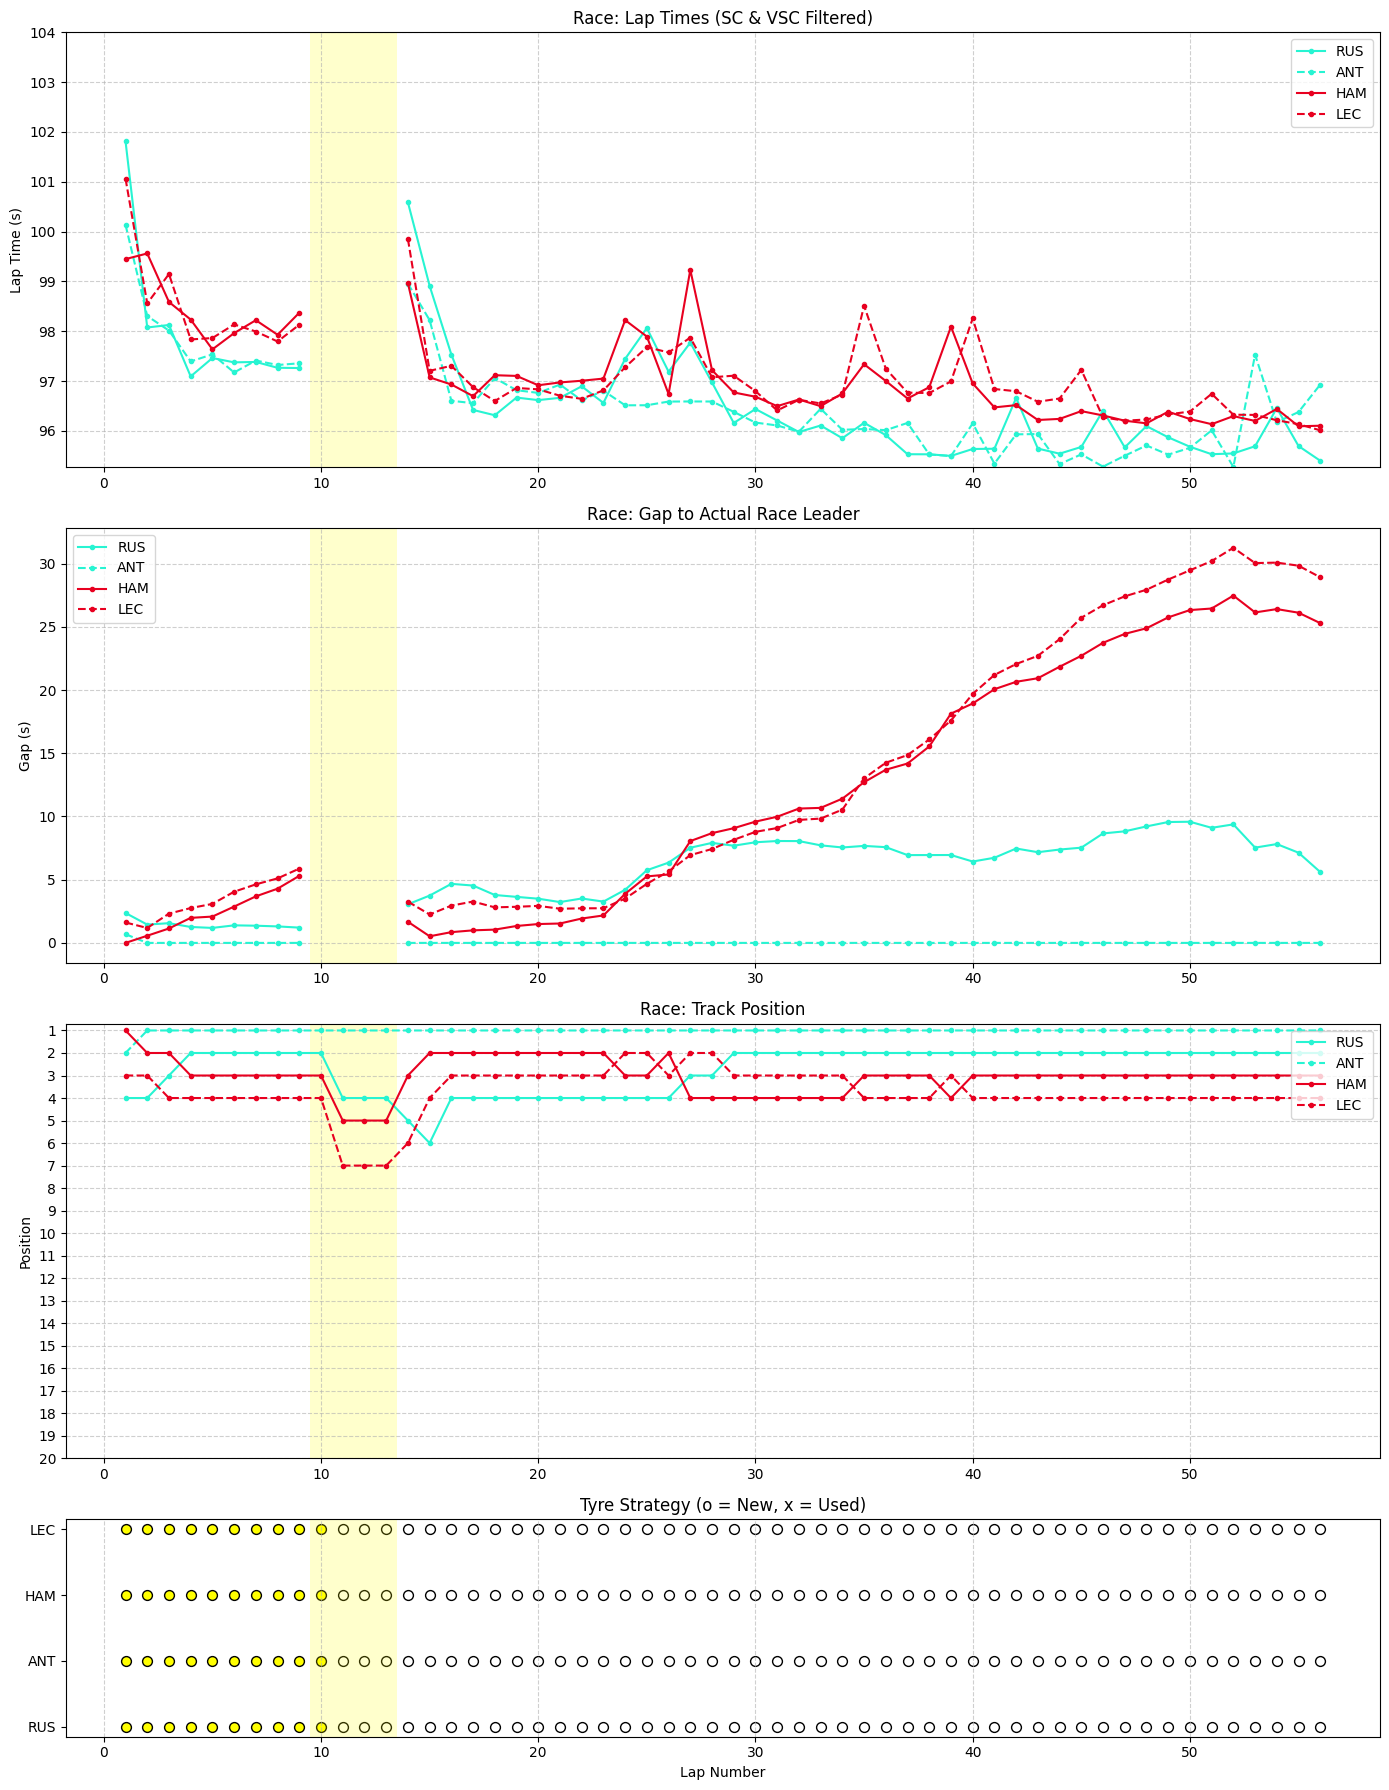

In [28]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# 0. 初期設定とセッションの読み込み
# =========================================================
fastf1.Cache.enable_cache('cache')
fastf1.plotting.setup_mpl()

# セッションを読み込み（2026年 中国GP 決勝レース）
session_r = fastf1.get_session(2026, 'China', 'R')
session_r.load()
laps_r = session_r.laps

# =========================================================
# 1. データの前処理
# =========================================================
# 分析対象のドライバー設定（上位4台にフォーカス）
drivers = ['RUS', 'ANT', 'HAM', 'LEC'] 

# SC/VSCのラップを空欄(NaN)にする関数
def filter_sc_vsc(row):
    status = str(row['TrackStatus'])
    if '4' in status or '6' in status or '7' in status:
        return np.nan
    time = row['LapTime']
    return time.total_seconds() if pd.notnull(time) else np.nan

# クリーンなラップタイム列を作成
laps_r['CleanLapTime'] = laps_r.apply(filter_sc_vsc, axis=1)

# =========================================================
# 2. グラフ設定と共通関数
# =========================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 18), gridspec_kw={'height_ratios': [2, 2, 2, 1]})

# SC/VSCが発生したラップを特定し、背景を黄色に塗る関数
sc_vsc_laps = laps_r[laps_r['TrackStatus'].astype(str).str.contains('4|6|7')]['LapNumber'].unique()

def add_sc_vsc_shading(ax):
    for lap in sc_vsc_laps:
        ax.axvspan(lap - 0.5, lap + 0.5, color='yellow', alpha=0.2, lw=0)

# 色かぶり対策：ドライバーごとの線のスタイルを事前決定
driver_styles = {}
color_counts = {}

for drv in drivers:
    color = fastf1.plotting.get_driver_color(drv, session_r)
    if color not in color_counts:
        color_counts[color] = 0
    color_counts[color] += 1
    
    # 1人目=実線, 2人目=破線, 3人目=点線
    if color_counts[color] == 1:
        ls = '-'
    elif color_counts[color] == 2:
        ls = '--'
    else:
        ls = ':'
        
    driver_styles[drv] = {'color': color, 'linestyle': ls}

# =========================================================
# ① ラップタイムの推移
# =========================================================
for drv in drivers:
    drv_laps = laps_r.pick_driver(drv)
    color = driver_styles[drv]['color']
    ls = driver_styles[drv]['linestyle']
    
    axes[0].plot(drv_laps['LapNumber'], drv_laps['CleanLapTime'], 
                 label=drv, color=color, linestyle=ls, marker='.')

axes[0].set_title('Race: Lap Times (SC & VSC Filtered)')
axes[0].set_ylabel('Lap Time (s)')
# Y軸の上限を104秒に設定して上位陣の争いをズームアップ
axes[0].set_ylim(bottom=np.nanmin(laps_r['CleanLapTime']), top=104) 
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)
add_sc_vsc_shading(axes[0])

# =========================================================
# ② 実際のレースリーダー（その都度1位）とのギャップ推移
# =========================================================
# その周回でPosition（順位）が1位だったマシンのタイムを真のリーダータイムとして抽出
actual_leader_laps = laps_r[laps_r['Position'] == 1].groupby('LapNumber')['Time'].min().reset_index()
actual_leader_laps.rename(columns={'Time': 'LeaderTime'}, inplace=True)

for drv in drivers:
    drv_laps = laps_r.pick_driver(drv)[['LapNumber', 'Time', 'TrackStatus']]
    color = driver_styles[drv]['color']
    ls = driver_styles[drv]['linestyle']
    
    # ドライバーと実際のリーダーのデータをラップナンバーで結合
    merged = pd.merge(drv_laps, actual_leader_laps, on='LapNumber')
    
    # 真のリーダーとのギャップ（秒）を計算
    merged['Gap'] = (merged['Time'] - merged['LeaderTime']).dt.total_seconds()
    
    # SC/VSC中のラップはギャップをNaNにして線を切断する（ノイズ除去）
    mask_sc_vsc = merged['TrackStatus'].astype(str).str.contains('4|6|7')
    merged.loc[mask_sc_vsc, 'Gap'] = np.nan
    
    axes[1].plot(merged['LapNumber'], merged['Gap'], 
                 label=drv, color=color, linestyle=ls, marker='.')

axes[1].set_title('Race: Gap to Actual Race Leader')
axes[1].set_ylabel('Gap (s)')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)
add_sc_vsc_shading(axes[1])

# =========================================================
# ③ 順位（ポジション）の推移
# =========================================================
for drv in drivers:
    drv_laps = laps_r.pick_driver(drv)[['LapNumber', 'Position']]
    color = driver_styles[drv]['color']
    ls = driver_styles[drv]['linestyle']
    
    axes[2].plot(drv_laps['LapNumber'], drv_laps['Position'], 
                 label=drv, color=color, linestyle=ls, marker='.')

axes[2].set_title('Race: Track Position')
axes[2].set_ylabel('Position')
axes[2].invert_yaxis() # 1位が一番上になるようにY軸を反転
axes[2].set_yticks(range(1, 21)) # Y軸の目盛りを1〜20位に設定
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle='--', alpha=0.6)
add_sc_vsc_shading(axes[2])

# =========================================================
# ④ タイヤの使用履歴・スティント
# =========================================================
compound_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white', 'INTERMEDIATE': 'green', 'WET': 'blue'}

for i, drv in enumerate(drivers):
    drv_laps = laps_r.pick_driver(drv)
    
    for _, lap in drv_laps.iterrows():
        comp = str(lap['Compound'])
        color = compound_colors.get(comp, 'grey')
        is_new = lap['FreshTyre'] == True
        marker = 'o' if is_new else 'x'
        
        # 【修正】edgecolors='black' を追加して、白のハードタイヤが見えるようにする
        axes[3].scatter(lap['LapNumber'], i, color=color, marker=marker, s=50, edgecolors='black', linewidth=1)

axes[3].set_title('Tyre Strategy (o = New, x = Used)')
axes[3].set_yticks(range(len(drivers)))
axes[3].set_yticklabels(drivers)
axes[3].set_xlabel('Lap Number')
axes[3].grid(True, axis='x', linestyle='--', alpha=0.6)
add_sc_vsc_shading(axes[3])

# =========================================================
# 描画の実行
# =========================================================
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# =========================================================
# 3. 決勝レースのタイヤ詳細情報
# =========================================================
# まずは基本的な情報を集計
stints = laps_r.groupby(['Driver', 'Stint']).agg({
    'Compound': 'first',
    'FreshTyre': 'first',
    'TyreLife': ['min', 'max'],
    'CleanLapTime': 'mean'
}).reset_index()

stints.columns = ['Driver', 'Stint', 'Compound', 'Is_New', 'Start_Age', 'End_Age', 'Avg_Clean_Lap(s)']

# --- 【追加】デグラデーション（傾き）を計算する関数 ---
def calculate_degradation(group):
    # SC/VSCなどの空欄(NaN)を除外
    df = group.dropna(subset=['CleanLapTime', 'TyreLife'])
    
    # データが少なすぎる（3周未満）場合は計算できないので空欄にする
    if len(df) < 3:
        return np.nan
    
    # 一次関数 (y = ax + b) でフィッティングし、傾き(a)を取得
    slope, intercept = np.polyfit(df['TyreLife'], df['CleanLapTime'], 1)
    return slope

# ドライバーとスティントごとにデグラデーションを計算
deg_df = laps_r.groupby(['Driver', 'Stint']).apply(calculate_degradation).reset_index(name='Deg_Per_Lap(s)')

# 計算したデグラデーションの列を元の表に合体させる
stints = pd.merge(stints, deg_df, on=['Driver', 'Stint'])

# 見やすいように小数点以下3桁に丸める
stints['Avg_Clean_Lap(s)'] = stints['Avg_Clean_Lap(s)'].round(3)
stints['Deg_Per_Lap(s)'] = stints['Deg_Per_Lap(s)'].round(3)

print("\n【決勝レース：タイヤ使用履歴と平均ペース・デグラデーション詳細】")
print(stints[stints['Driver'].isin(drivers)])


【決勝レース：タイヤ使用履歴と平均ペース・デグラデーション詳細】
   Driver  Stint Compound  Is_New  Start_Age  End_Age  Avg_Clean_Lap(s)  \
3     ANT    1.0   MEDIUM    True        1.0     10.0            97.850   
4     ANT    2.0     HARD    True        1.0     46.0            96.294   
17    HAM    1.0   MEDIUM    True        1.0     10.0            98.439   
18    HAM    2.0     HARD    True        1.0     46.0            96.843   
23    LEC    1.0   MEDIUM    True        1.0     10.0            98.502   
24    LEC    2.0     HARD    True        1.0     46.0            96.911   
34    RUS    1.0   MEDIUM    True        1.0     10.0            97.984   
35    RUS    2.0     HARD    True        1.0     46.0            96.391   

    Deg_Per_Lap(s)  
3           -0.258  
4           -0.035  
17          -0.170  
18          -0.035  
23          -0.267  
24          -0.029  
34          -0.364  
35          -0.055  


/var/folders/4k/q0_phzj110jfps2bngfqm0tm0000gn/T/ipykernel_36776/1512719911.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  deg_df = laps_r.groupby(['Driver', 'Stint']).apply(calculate_degradation).reset_index(name='Deg_Per_Lap(s)')


/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_dr

抽出区間: Turn 13 (3423.3m) 〜 Turn 14 (4787.9m)


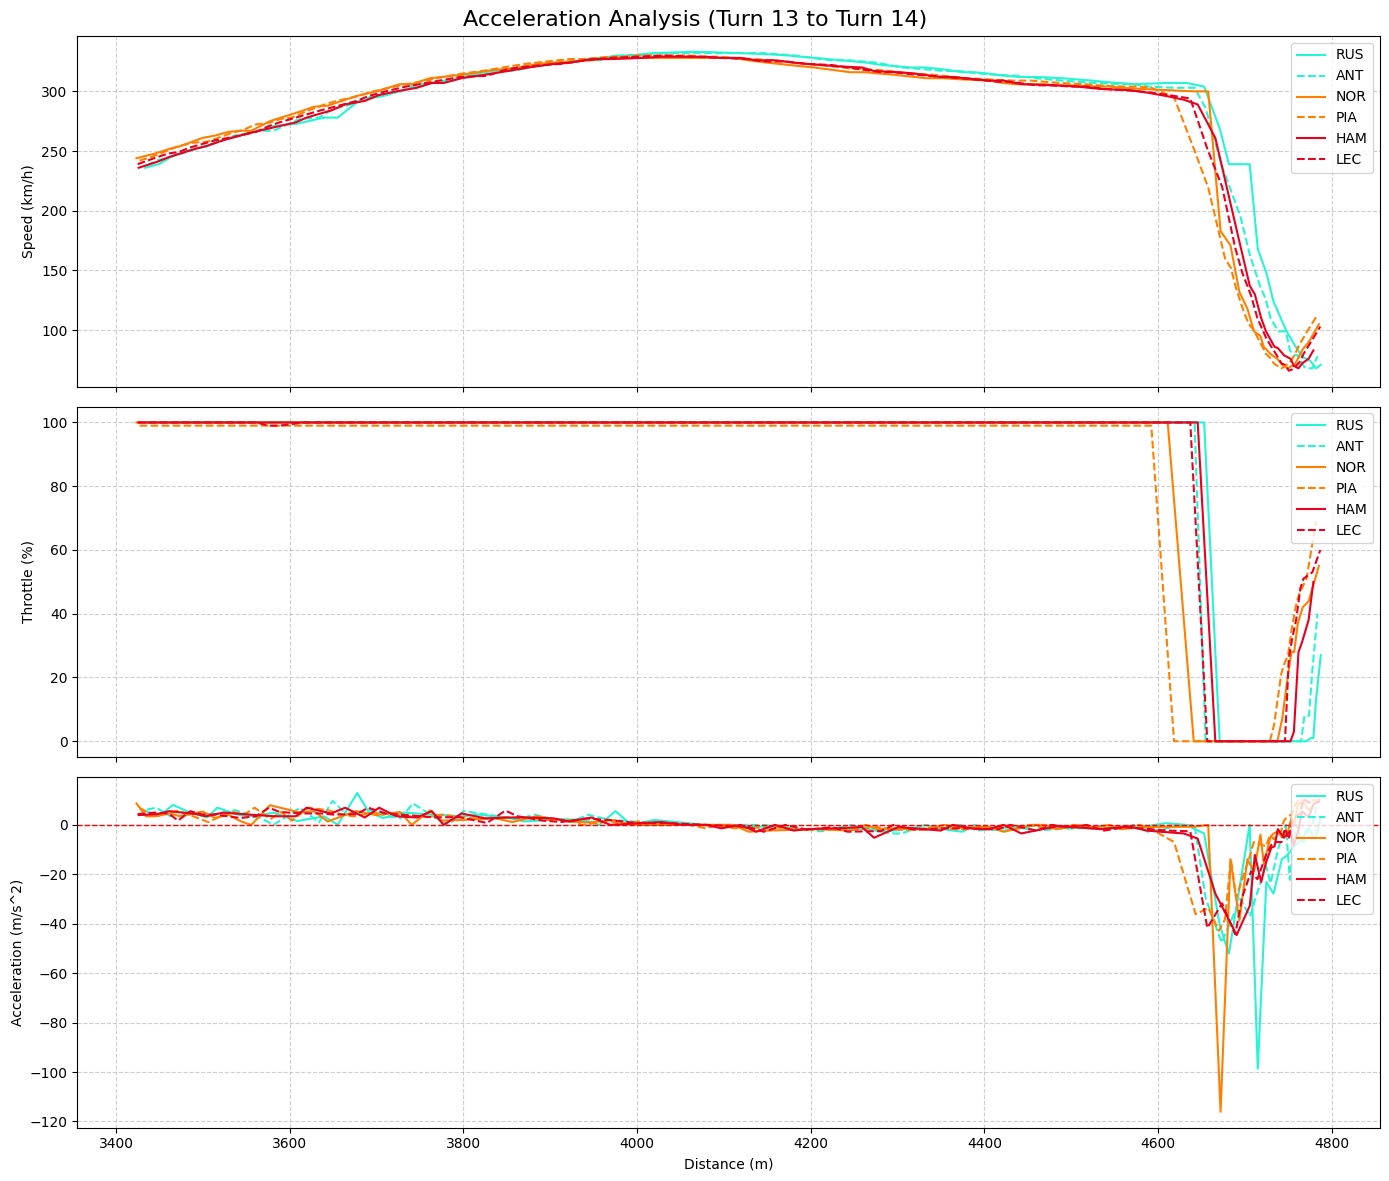

In [30]:
# =========================================================
# 分析対象のドライバー設定
# =========================================================
# 先ほどのRUSに加え、ご指定のドライバーを追加
drivers = ['RUS', 'ANT', 'NOR', 'PIA', 'HAM', 'LEC']

# =========================================================
# サーキット情報から特定のコーナー区間を自動抽出
# =========================================================
circuit_info = session_sq.get_circuit_info()
t13_dist = circuit_info.corners.loc[circuit_info.corners['Number'] == 13, 'Distance'].values[0]
t14_dist = circuit_info.corners.loc[circuit_info.corners['Number'] == 14, 'Distance'].values[0]

print(f"抽出区間: Turn 13 ({t13_dist:.1f}m) 〜 Turn 14 ({t14_dist:.1f}m)")

# =========================================================
# 色かぶり対策：ドライバーごとの線のスタイルを事前決定
# =========================================================
driver_styles = {}
color_counts = {}

for drv in drivers:
    color = fastf1.plotting.get_driver_color(drv, session_sq)
    if color not in color_counts:
        color_counts[color] = 0
    color_counts[color] += 1
    
    # 1人目は実線、2人目（チームメイト）は破線
    if color_counts[color] == 1:
        ls = '-'
    else:
        ls = '--'
        
    driver_styles[drv] = {'color': color, 'linestyle': ls}

# =========================================================
# グラフの初期設定
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# =========================================================
# 各ドライバーのデータをループ処理で取得・計算・描画
# =========================================================
for drv in drivers:
    # 対象ドライバーの最速ラップデータを抽出
    lap = sq_laps.pick_driver(drv).iloc[0]
    
    # テレメトリーデータ（距離付き）を取得
    tel = lap.get_car_data().add_distance()
    
    # 時間を秒に、速度をm/sに変換
    tel['Time_sec'] = tel['Time'].dt.total_seconds()
    tel['Speed_ms'] = tel['Speed'] / 3.6
    
    # 【追加反映】スロットルの上限を100に強制カット
    tel['Throttle'] = tel['Throttle'].clip(upper=100)
    
    # 加速度 (m/s^2) の算出
    tel['Acceleration'] = tel['Speed_ms'].diff() / tel['Time_sec'].diff().replace(0, np.nan)
    
    # ターン13〜ターン14の距離でフィルタリング
    mask_dist = (tel['Distance'] >= t13_dist) & (tel['Distance'] <= t14_dist)
    tel_straight = tel[mask_dist]
    
    # 割り当てられた色と線のスタイルを取得
    color = driver_styles[drv]['color']
    ls = driver_styles[drv]['linestyle']
    
    # グラフへのプロット
    axes[0].plot(tel_straight['Distance'], tel_straight['Speed'], 
                 color=color, linestyle=ls, label=drv)
    
    axes[1].plot(tel_straight['Distance'], tel_straight['Throttle'], 
                 color=color, linestyle=ls, label=drv)
    
    axes[2].plot(tel_straight['Distance'], tel_straight['Acceleration'], 
                 color=color, linestyle=ls, label=drv)

# =========================================================
# グラフの装飾・体裁を整える
# =========================================================
axes[0].set_ylabel('Speed (km/h)')
axes[0].legend(loc='upper right') # ← ここを 'lower right' から 'upper right' に変更
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_ylabel('Throttle (%)')
axes[1].legend(loc='upper right') # ← ここも 'lower right' から 'upper right' に変更
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].axhline(0, color='red', linestyle='--', linewidth=1) 
axes[2].set_xlabel('Distance (m)')
axes[2].set_ylabel('Acceleration (m/s^2)')
axes[2].legend(loc='upper right') # ← ここは元から 'upper right' ならそのままでOK
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Acceleration Analysis (Turn 13 to Turn 14)", fontsize=16)
plt.tight_layout()
plt.show()